In [1]:
print('MAC simulation Hello')

MAC simulation Hello


In [2]:
class Station:
    def __init__(self, station_id, K, tau, lam):
        self.id = station_id
        self.K = K
        self.tau = tau
        self.lam = lam
        
        # Queue state
        self.packet_count = 0  # Counter used instead of a list
        
        # MAC protocol state
        self.state_i = 1       # Current exponent for 2^i
        self.collision_flag = False  # Flag: "someone collided with me"
        self.my_planned_end = 0.0    # My transmission end timestamp
        
        # Waiting flag: to avoid starting a new transmission 
        # while in Backoff mode vg
        self.is_waiting_backoff = False

    def is_full(self):
        return self.packet_count >= self.K

    def add_packet(self):
        if not self.is_full():
            self.packet_count += 1
            return True
        return False

    def remove_packet(self):
        if self.packet_count > 0:
            self.packet_count -= 1

    def get_backoff_delay(self):
        """Calculates random delay according to Exp(1 / (2^i * tau)) law"""
        mean_delay = (2**self.state_i) * self.tau
        return random.expovariate(1.0 / mean_delay)

    def check_canal_collision(self, current_time, canal):
        """
        Universal collision check method.
        Called twice: at START_TX and at END_TX.
        """
        # 1. Logic for START_TX moment
        if current_time < self.my_planned_end: 
            # This means the method is called at the start of transmission.
            # Check if the channel is occupied by someone else right now.
            last_end_in_canal = canal.update_and_get(self.my_planned_end)
            if last_end_in_canal > current_time:
                self.collision_flag = True
        
        # 2. Logic for END_TX moment
        else:
            # Method called at the completion moment (current_time >= my_planned_end).
            # Check if someone overwrote our "timestamp" during the broadcast.
            if canal.end_time != self.my_planned_end:
                self.collision_flag = True

    def handle_event(self, event, canal, pq, current_time, stats):
        if event.type == Event.ARRIVAL:
            self._handle_arrival(current_time, pq, stats)
        elif event.type == Event.START_TX:
            self._handle_start_tx(current_time, canal, pq)
        elif event.type == Event.END_TX:
            self._handle_end_tx(current_time, canal, pq, stats)

    def _handle_arrival(self, current_time, pq, stats):
        # 1. Schedule next arrival vg
        next_arrival = current_time + random.expovariate(self.lam) # Use station's lam
        heapq.heappush(pq, Event(next_arrival, Event.ARRIVAL, self.id))
        
        # 2. Try to buffer the packet
        if self.add_packet():
            stats.record_arrival(current_time, dropped=False) # RECORD ARRIVAL
            if self.packet_count == 1 and not self.is_waiting_backoff:
                heapq.heappush(pq, Event(current_time, Event.START_TX, self.id))
        else:
            stats.record_arrival(current_time, dropped=True) # RECORD LOSS

    def _handle_start_tx(self, current_time, canal, pq):
        self.is_waiting_backoff = False 
        self.my_planned_end = current_time + 1.0 
        self.check_canal_collision(current_time, canal)
        heapq.heappush(pq, Event(self.my_planned_end, Event.END_TX, self.id))

    def _handle_end_tx(self, current_time, canal, pq, stats):
        self.check_canal_collision(current_time, canal)
        
        if self.collision_flag:
            self.collision_flag = False 
            self.state_i += 1            
            
            delay = self.get_backoff_delay()
            self.is_waiting_backoff = True
            heapq.heappush(pq, Event(current_time + delay, Event.START_TX, self.id))
        else:
            # SUCCESS
            self.remove_packet()
            self.state_i = 1 
            stats.record_success(current_time) # RECORD SUCCESS FOR PLOTTING
            
            if self.packet_count > 0:
                heapq.heappush(pq, Event(current_time, Event.START_TX, self.id))

print('class Station created')

class Station created


In [3]:
class Event:
    # Event types (Enum-like)
    ARRIVAL = 0
    START_TX = 1
    END_TX = 2

    def __init__(self, time, event_type, station_id):
        self.time = time
        self.type = event_type
        self.station_id = station_id

    # Necessary for heapq: sorts by ascending time
    def __lt__(self, other):
        return self.time < other.time

print('Class event created')

Class event created


In [4]:
class Canal:
    def __init__(self):
        self.end_time = 0.0
        
    def update_and_get(self, t_end):
        old_end = self.end_time
        self.end_time = t_end
        return old_end
print('Class canal created')

Class canal created


In [5]:
class Statistics:
    def __init__(self):
        # Counters
        self.total_arrivals = 0
        self.total_dropped = 0
        self.total_successes = 0
        
        # Integral metrics
        self.area_packets = 0.0
        self.last_event_time = 0.0
        
        # History for plots (time, value)
        self.throughput_history = []     # n(t)/t
        self.packet_avg_history = []     # Average number of clients
        self.loss_rate_history = []      # Loss probability trajectory

    def record_arrival(self, current_time, dropped=False):
        self.total_arrivals += 1
        if dropped:
            self.total_dropped += 1
        
        # Add entry to history for the loss rate plot
        if current_time > 0:
            self.loss_rate_history.append((current_time, self.total_dropped / self.total_arrivals))

    def record_success(self, current_time):
        self.total_successes += 1
        if current_time > 0:
            self.throughput_history.append((current_time, self.total_successes / current_time))

    def update_area(self, current_time, total_packets):
        duration = current_time - self.last_event_time
        if duration > 0:
            self.area_packets += total_packets * duration
            self.last_event_time = current_time
            # Record for the average number of clients plot
            self.packet_avg_history.append((current_time, self.area_packets / current_time))

    # --- Getters for final results ---
    def get_final_metrics(self, total_time):
        return {
            "throughput": self.total_successes / total_time if total_time > 0 else 0,
            "loss_probability": self.total_dropped / self.total_arrivals if self.total_arrivals > 0 else 0,
            "avg_packets": self.area_packets / total_time if total_time > 0 else 0
        }

print('class statistics created')

class statistics created


In [8]:
def run_simulation(N, K, Lambda, Tau, T_max):
    """
    Starts one simulation cycle of the Exponential Backoff system.
    Returns a dictionary containing parameters and results.
    """

    import random
    import heapq
    
    # 1. Initialize objects inside the function
    canal = Canal()
    stats = Statistics()
    stations = [Station(i, K, Tau, Lambda) for i in range(N)]
    pq = []
    
    # 2. Initial pulse
    for s in stations:
        first_arrival = random.expovariate(s.lam)
        heapq.heappush(pq, Event(first_arrival, Event.ARRIVAL, s.id))

    # 3. Main loop
    while pq:
        event = heapq.heappop(pq)
        
        if event.time > T_max:
            break
            
        # Update integral metrics
        total_p = sum(st.packet_count for st in stations)
        stats.update_area(event.time, total_p)
        
        # Pass event to the target station
        target_station = stations[event.station_id]
        target_station.handle_event(event, canal, pq, event.time, stats)
    
    # 4. Generate the extended report
    results = stats.get_final_metrics(T_max)
    
    # Merge input parameters and results into a single dictionary
    report = {
        # Parameters (Input)
        'N': N,
        'K': K,
        'Lambda': Lambda,
        'Tau': Tau,
        'T_max': T_max,
        # Results (Output)
        'throughput': results['throughput'],
        'loss_probability': results['loss_probability'],
        'avg_packets': results['avg_packets'],
        # Also return history for "vs time" plots
        'history_throughput': stats.throughput_history,
        'history_packets': stats.packet_avg_history,
        'history_loss': stats.loss_rate_history
    }
    
    return report

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
import heapq

# 1. Define the parameter grid
N_range = [1, 2, 5, 10, 15, 20, 30, 50, 100, 200, 300]
Lambda_range = [0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]

matrix_data = []

# 2. Nested loop
for n in N_range:
    row = {'N': n} # Start forming a row for the table
    for l in Lambda_range:
        # Run simulation (T_max set to 10000 for speed) vg
        res = run_simulation(N=n, K=5, Lambda=l, Tau=0.5, T_max=10000)
        
        # Record throughput in the cell, where the column is the Lambda value
        row[f'L_{l}'] = res['throughput']
        
    matrix_data.append(row)
    print(f"Calculation completed for N={n}")

# 3. Visualization as a table
df = pd.DataFrame(matrix_data).set_index('N')
print(df)

Calculation completed for N=1
Calculation completed for N=2
Calculation completed for N=5
Calculation completed for N=10
Calculation completed for N=15
Calculation completed for N=20
Calculation completed for N=30
Calculation completed for N=50
Calculation completed for N=100
Calculation completed for N=200
Calculation completed for N=300
     L_0.01  L_0.02  L_0.05  L_0.08   L_0.1  L_0.15   L_0.2   L_0.3   L_0.5  \
N                                                                             
1    0.0114  0.0211  0.0502  0.0835  0.0989  0.1517  0.1951  0.2993  0.5033   
2    0.0214  0.0401  0.1048  0.1578  0.1935  0.2792  0.3087  0.3353  0.4962   
5    0.0480  0.1008  0.1962  0.2381  0.2609  0.2808  0.3298  0.3611  0.4965   
10   0.1020  0.1777  0.2414  0.2608  0.2741  0.3085  0.3195  0.3688  0.4721   
15   0.1473  0.1980  0.2410  0.2566  0.2792  0.2945  0.3292  0.3673  0.4742   
20   0.1761  0.2185  0.2430  0.2784  0.2771  0.3161  0.3235  0.3676  0.4696   
30   0.2038  0.2261  0.2558

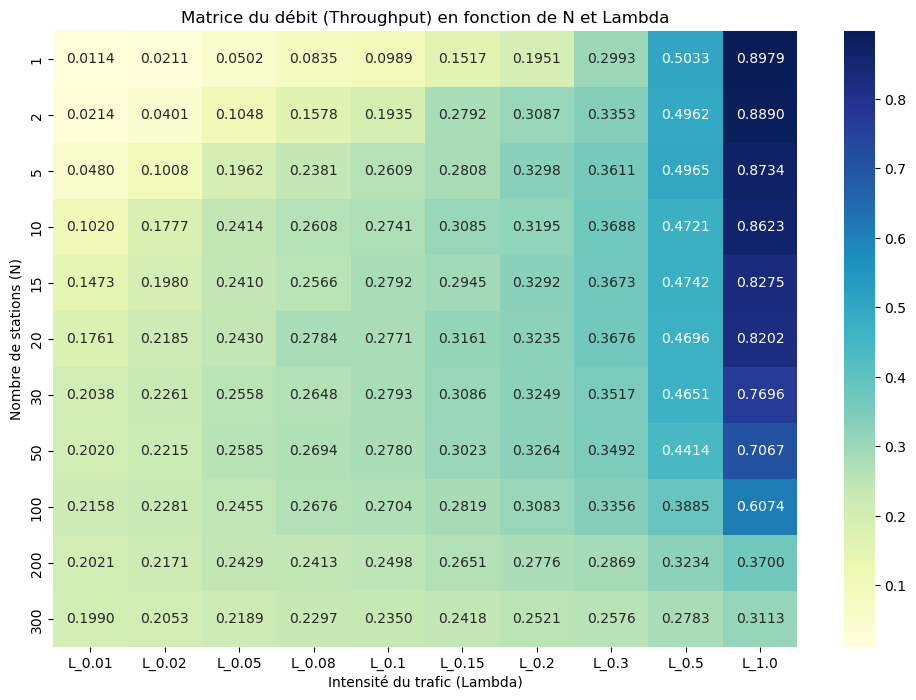

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df, annot=True, fmt=".4f", cmap='YlGnBu') # fmt=".4f" для красоты цифр
plt.title('Matrice du débit (Throughput) en fonction de N et Lambda')
plt.xlabel('Intensité du trafic (Lambda)')
plt.ylabel('Nombre de stations (N)')

# Сохранение для LaTeX
# plt.savefig('heatmap_results.pdf', bbox_inches='tight') 
plt.show()

All figures have been saved to 'Simulation_Report_Plots.pdf'


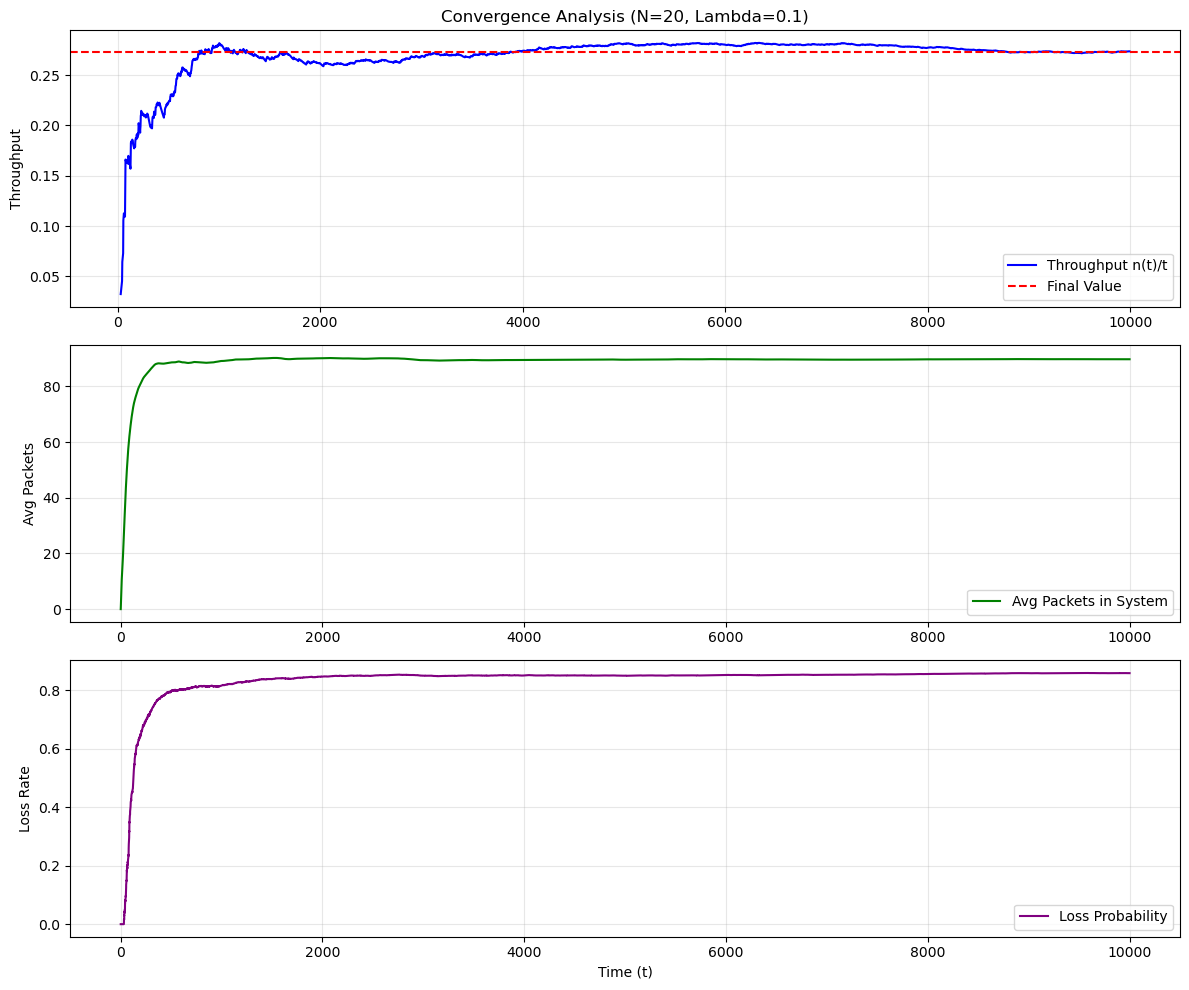

Final steady-state throughput: 0.2734


In [17]:
import matplotlib.pyplot as plt

# --- 1. Run a single long simulation to observe convergence ---
# We use a large T_MAX to ensure the system reaches a steady state
N_test, K_test, L_test, T_test, T_max_long = 20, 5, 0.1, 0.5, 10000
report = run_simulation(N_test, K_test, L_test, T_test, T_max_long)

# --- 2. Extract History Data ---
# Unpack tuples (time, value) from the report histories
time_thr, val_thr = zip(*report['history_throughput'])
time_pax, val_pax = zip(*report['history_packets'])
time_loss, val_loss = zip(*report['history_loss'])

# --- 3. Plotting ---
plt.figure(figsize=(12, 10))

# Subplot A: Throughput convergence n(t)/t
plt.subplot(3, 1, 1)
plt.plot(time_thr, val_thr, color='blue', label='Throughput n(t)/t')
plt.axhline(y=report['throughput'], color='red', linestyle='--', label='Final Value')
plt.title(f'Convergence Analysis (N={N_test}, Lambda={L_test})')
plt.ylabel('Throughput')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot B: Average Number of Packets (Queue occupancy) vg
plt.subplot(3, 1, 2)
plt.plot(time_pax, val_pax, color='green', label='Avg Packets in System')
plt.ylabel('Avg Packets')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot C: Loss Rate convergence
plt.subplot(3, 1, 3)
plt.plot(time_loss, val_loss, color='purple', label='Loss Probability')
plt.xlabel('Time (t)')
plt.ylabel('Loss Rate')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

from matplotlib.backends.backend_pdf import PdfPages

# Initialize the PDF file
with PdfPages('Simulation_Report_Plots.pdf') as pdf:
    
    # --- PAGE 1: Convergence Plots ---
    plt.figure(figsize=(12, 10))
    # ... (your plotting code for convergence) ...
    plt.tight_layout()
    pdf.savefig()  # Saves the current figure to the PDF
    plt.close()    # Close the figure to free up memory

    # --- PAGE 2: Throughput vs Lambda ---
    plt.figure(figsize=(10, 6))
    # ... (your plotting code for Lambda variation) ...
    plt.tight_layout()
    pdf.savefig() 
    plt.close()

print("All figures have been saved to 'Simulation_Report_Plots.pdf'")
plt.show()

# Final output for report confirmation
print(f"Final steady-state throughput: {report['throughput']:.4f}")

In [15]:
# ... (after all your plt.plot and plt.title commands) ...

plt.tight_layout()

# Save the figure in PDF format
# 'bbox_inches="tight"' removes unnecessary white margins
plt.savefig("convergence_plots.pdf", format="pdf", bbox_inches="tight")

print("File 'convergence_plots.pdf' has been saved successfully.") 

File 'convergence_plots.pdf' has been saved successfully.


<Figure size 640x480 with 0 Axes>

In [16]:
from matplotlib.backends.backend_pdf import PdfPages

# Initialize the PDF file
with PdfPages('Simulation_Report_Plots.pdf') as pdf:
    
    # --- PAGE 1: Convergence Plots ---
    plt.figure(figsize=(12, 10))
    # ... (your plotting code for convergence) ...
    plt.tight_layout()
    pdf.savefig()  # Saves the current figure to the PDF
    plt.close()    # Close the figure to free up memory

    # --- PAGE 2: Throughput vs Lambda ---
    plt.figure(figsize=(10, 6))
    # ... (your plotting code for Lambda variation) ...
    plt.tight_layout()
    pdf.savefig() 
    plt.close()

print("All figures have been saved to 'Simulation_Report_Plots.pdf'")

All figures have been saved to 'Simulation_Report_Plots.pdf'


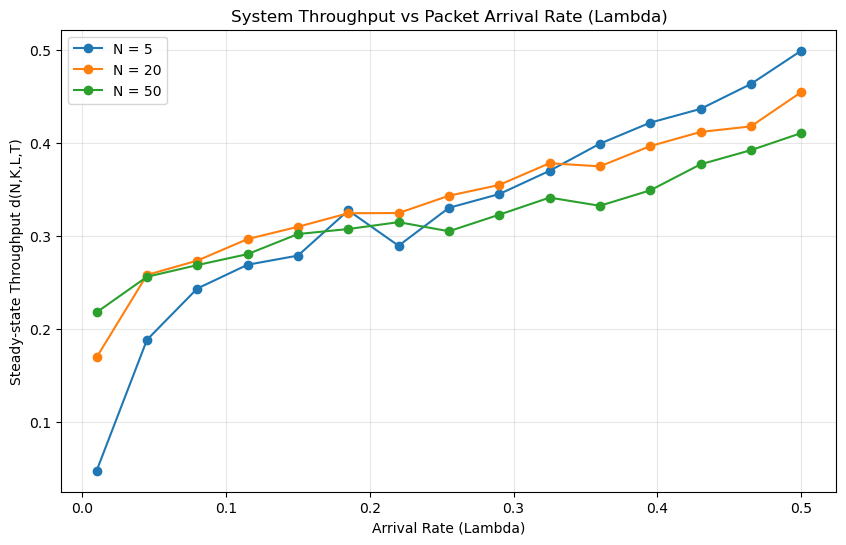

In [18]:
# --- 2. Throughput vs Lambda (for different N) ---
import numpy as np

N_values = [5, 20, 50] # Test for small, medium, and large networks
Lambda_range = np.linspace(0.01, 0.5, 15) # From light to heavy traffic

plt.figure(figsize=(10, 6))

for n in N_values:
    throughputs = []
    for l in Lambda_range:
        # T_max=5000 is enough for these point-to-point plots
        res = run_simulation(N=n, K=5, Lambda=l, Tau=0.5, T_max=5000)
        throughputs.append(res['throughput'])
    
    plt.plot(Lambda_range, throughputs, marker='o', label=f'N = {n}')

# English labels for the report
plt.title('System Throughput vs Packet Arrival Rate (Lambda)')
plt.xlabel('Arrival Rate (Lambda)')
plt.ylabel('Steady-state Throughput d(N,K,L,T)')
plt.legend()
plt.grid(True, alpha=0.3)

# CRITICAL: Save BEFORE show
plt.savefig("throughput_vs_lambda.pdf", bbox_inches="tight")
plt.show() # Optional: display on screen after saving

Starting optimization runs with 95% confidence intervals...
Done for N=5
Done for N=10
Done for N=15
Done for N=20
Done for N=25
Done for N=30
Done for N=35
Done for N=40


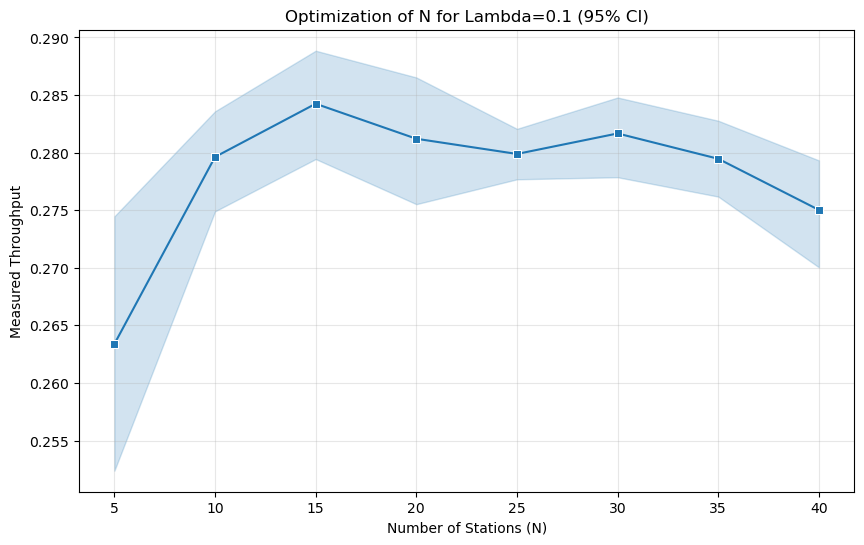

In [19]:
import seaborn as sns

# Parameters for the optimization task
Lambda_fixed = 0.1
N_range = range(5, 41, 5) # Testing N = 5, 10, 15... 40
iterations = 10           # Run 10 simulations for each N to get statistics

data_list = []

print("Starting optimization runs with 95% confidence intervals...")

for n in N_range:
    for i in range(iterations):
        res = run_simulation(N=n, K=5, Lambda=Lambda_fixed, Tau=0.5, T_max=5000)
        data_list.append({'N': n, 'Throughput': res['throughput']})
    print(f"Done for N={n}")

# Create DataFrame
df_opt = pd.DataFrame(data_list)

# Plotting
plt.figure(figsize=(10, 6))
# ci=95 tells seaborn to calculate the 95% confidence interval
sns.lineplot(data=df_opt, x='N', y='Throughput', marker='s', errorbar=('ci', 95))

plt.title(f'Optimization of N for Lambda={Lambda_fixed} (95% CI)')
plt.xlabel('Number of Stations (N)')
plt.ylabel('Measured Throughput')
plt.grid(True, alpha=0.3)

# Save BEFORE show
plt.savefig("optimization_n_95ci.pdf", bbox_inches="tight")
plt.show()

In [20]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import seaborn as sns
import pandas as pd

# 1. Prepare data for Page 1 (Convergence)
N_test, K_test, L_test, T_test, T_max_long = 20, 5, 0.1, 0.5, 10000
report = run_simulation(N_test, K_test, L_test, T_test, T_max_long)

# Initialize the PDF file
with PdfPages('Simulation_Report_Plots.pdf') as pdf:
    
    # --- PAGE 1: CONVERGENCE PLOTS ---
    fig1 = plt.figure(figsize=(12, 10))
    
    time_thr, val_thr = zip(*report['history_throughput'])
    time_pax, val_pax = zip(*report['history_packets'])
    time_loss, val_loss = zip(*report['history_loss'])

    plt.subplot(3, 1, 1)
    plt.plot(time_thr, val_thr, color='blue', label='Throughput n(t)/t')
    plt.axhline(y=report['throughput'], color='red', linestyle='--', label='Final Value')
    plt.title(f'Convergence Analysis (N={N_test}, Lambda={L_test})')
    plt.ylabel('Throughput')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(time_pax, val_pax, color='green', label='Avg Packets in System')
    plt.ylabel('Avg Packets')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(time_loss, val_loss, color='purple', label='Loss Probability')
    plt.xlabel('Time (t)')
    plt.ylabel('Loss Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    pdf.savefig(fig1)  # Save Page 1
    plt.close(fig1)
    print("Page 1 (Convergence) added.")

    # --- PAGE 2: THROUGHPUT VS LAMBDA ---
    fig2 = plt.figure(figsize=(10, 6))
    N_values = [5, 20, 50]
    Lambda_range = np.linspace(0.01, 0.5, 10) # 10 points for speed

    for n in N_values:
        thr_list = [run_simulation(n, 5, l, 0.5, 5000)['throughput'] for l in Lambda_range]
        plt.plot(Lambda_range, thr_list, marker='o', label=f'N = {n}')

    plt.title('System Throughput vs Lambda')
    plt.xlabel('Lambda')
    plt.ylabel('Throughput')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    pdf.savefig(fig2)  # Save Page 2
    plt.close(fig2)
    print("Page 2 (Throughput vs Lambda) added.")

    # --- PAGE 3: OPTIMIZATION WITH 95% CI ---
    fig3 = plt.figure(figsize=(10, 6))
    L_fixed = 0.1
    N_range = [5, 10, 15, 20, 25, 30, 40]
    data_opt = []
    
    for n in N_range:
        for _ in range(5): # 5 iterations per N for the CI
            res = run_simulation(n, 5, L_fixed, 0.5, 5000)
            data_opt.append({'N': n, 'Throughput': res['throughput']})
    
    df_opt = pd.DataFrame(data_opt)
    sns.lineplot(data=df_opt, x='N', y='Throughput', marker='s', errorbar=('ci', 95))
    
    plt.title(f'Optimization of N for Lambda={L_fixed} (95% CI)')
    plt.grid(True, alpha=0.3)
    
    pdf.savefig(fig3)  # Save Page 3
    plt.close(fig3)
    print("Page 3 (Optimization) added.")

print("\nSUCCESS: All figures saved to 'Simulation_Report_Plots.pdf'")

Page 1 (Convergence) added.
Page 2 (Throughput vs Lambda) added.
Page 3 (Optimization) added.

SUCCESS: All figures saved to 'Simulation_Report_Plots.pdf'


In [21]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# --- 1. Параметры и запуск симуляции ---
N_test, K_test, L_test, T_test, T_max_long = 20, 5, 0.1, 0.5, 10000
report = run_simulation(N_test, K_test, L_test, T_test, T_max_long)

# --- 2. Подготовка файла PDF ---
with PdfPages('Convergence_Report.pdf') as pdf:
    
    # Создаем фигуру
    fig = plt.figure(figsize=(12, 10))
    
    # Извлекаем данные из истории
    time_thr, val_thr = zip(*report['history_throughput'])
    time_pax, val_pax = zip(*report['history_packets'])
    time_loss, val_loss = zip(*report['history_loss'])

    # График А: Сходимость дебита (Throughput)
    plt.subplot(3, 1, 1)
    plt.plot(time_thr, val_thr, color='blue', label='Throughput n(t)/t')
    plt.axhline(y=report['throughput'], color='red', linestyle='--', label='Steady-state value')
    plt.title(f'Convergence Analysis (N={N_test}, Lambda={L_test}, T_max={T_max_long})')
    plt.ylabel('Throughput')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График Б: Среднее количество пакетов в системе
    plt.subplot(3, 1, 2)
    plt.plot(time_pax, val_pax, color='green', label='Avg Packets in System')
    plt.ylabel('Avg Packets')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График В: Вероятность потери пакетов
    plt.subplot(3, 1, 3)
    plt.plot(time_loss, val_loss, color='purple', label='Loss Probability')
    plt.xlabel('Time (t)')
    plt.ylabel('Loss Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    
    # Сохраняем страницу и закрываем фигуру
    pdf.savefig(fig)
    plt.close(fig)

print("SUCCESS: 'Convergence_Report.pdf' has been created with Page 1.")

SUCCESS: 'Convergence_Report.pdf' has been created with Page 1.


In [33]:
def hill_climbing_n_robust(start_n, Lambda, K, Tau, T_max, m_averaging=5):
    """
    I;proved Hill Climbing 

    """
    def get_stable_throughput(n):
        
        results = [run_simulation(N=n, K=K, Lambda=Lambda, Tau=Tau, T_max=T_max)['throughput'] 
                   for _ in range(m_averaging)]
        return sum(results) / m_averaging

    current_n = start_n
    total_simulations = 0
    
    current_throughput = get_stable_throughput(current_n)
    total_simulations += m_averaging
    
    print(f"Старт (усредненный): N={current_n}, Throughput={current_throughput:.4f}")
    
    iteration = 0
    while True:
        iteration += 1
        step = 1 
        neighbors = [current_n - step, current_n + step]
        neighbors = [n for n in neighbors if n >= 1]
        
        best_neighbor_n = current_n
        best_neighbor_throughput = current_throughput
        
        for neighbor_n in neighbors:
            thr_n = get_stable_throughput(neighbor_n)
            total_simulations += m_averaging
            
            if thr_n > best_neighbor_throughput:
                best_neighbor_throughput = thr_n
                best_neighbor_n = neighbor_n
        
        if best_neighbor_n != current_n:
            current_n = best_neighbor_n
            current_throughput = best_neighbor_throughput
            print(f"Iteration {iteration}: Step to N={current_n}, Throughput={current_throughput:.4f}")
        else:
            print(f"Iteration {iteration}: Average optimum found.")
            break
            
    return current_n, current_throughput, total_simulations


Lambda_test = 0.1
opt_n, opt_thr, sim_count = hill_climbing_n_robust(start_n=10, Lambda=Lambda_test, K=5, Tau=0.5, T_max=10000)

print("-" * 30)
print(f"Optimization results (Lambda={Lambda_test}):")
print(f"Optimal number of stations N N: {opt_n}")
print(f"Max debit: {opt_thr:.4f}")
print(f"Simulation count: {sim_count}")
print(f"Economy (if to compare to brut force N=300): {((1 - sim_count/300)*100):.1f}%")

Старт (усредненный): N=10, Throughput=0.2683
Iteration 1: Step to N=11, Throughput=0.2788
Iteration 2: Average optimum found.
------------------------------
Optimization results (Lambda=0.1):
Optimal number of stations N N: 11
Max debit: 0.2788
Simulation count: 25
Economy (if to compare to brut force N=300): 91.7%
